In [4]:
!pip install google-play-scraper

import pandas as pd
from google_play_scraper import Sort, reviews

# Google Play Store app ID for M-Paspor
app_id = 'id.go.imigrasi.paspor_online'

# Fetch reviews (e.g., 200 reviews)
result, continuation_token = reviews(
    app_id,
    lang='id', # Language for reviews
    country='id', # Country for reviews
    sort=Sort.NEWEST, # Sort by newest reviews
    count=200 # Number of reviews to fetch
)

# Convert to DataFrame
df_gplay = pd.DataFrame(result)

# 'content' for review text, 'score' for rating, 'at' for date
df_gplay = df_gplay[['content', 'score', 'at']]
df_gplay.columns = ['content', 'score', 'date']

df_gplay.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00


,content,score,date
0,layanan bagus,5,2026-04-15 07:29:33
1,sangat membantu,5,2026-04-15 06:00:29
2,bagus,5,2026-04-15 04:27:40
3,butuh pembaruan terus bilangnya tapi apk aja b...,1,2026-04-15 03:04:16
4,cukup mudah...,5,2026-04-15 01:02:35


### Informasi Dataset

In [5]:
print('Informasi Umum DataFrame:')
df_gplay.info()

print('\nStatistik Deskriptif DataFrame:')
display(df_gplay.describe(include='all'))

Informasi Umum DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   content  200 non-null    object        
 1   score    200 non-null    int64         
 2   date     200 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.8+ KB

Statistik Deskriptif DataFrame:


,content,score,date
count,200,200.000000,200
unique,194,NaN,NaN
top,ok,NaN,NaN
freq,3,NaN,NaN
mean,NaN,2.185000,2026-03-24 11:44:22.415000320
min,NaN,1.000000,2026-02-20 03:41:49
25%,NaN,1.000000,2026-03-13 09:09:35.500000
50%,NaN,1.000000,2026-03-28 07:14:31
75%,NaN,3.000000,2026-04-05 14:38:06.249999872
max,NaN,5.000000,2026-04-15 07:29:33


In [6]:
def label_sentimen(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df_gplay['label'] = df_gplay['score'].apply(label_sentimen)

display(df_gplay.head())

,content,score,date,label
0,layanan bagus,5,2026-04-15 07:29:33,positif
1,sangat membantu,5,2026-04-15 06:00:29,positif
2,bagus,5,2026-04-15 04:27:40,positif
3,butuh pembaruan terus bilangnya tapi apk aja b...,1,2026-04-15 03:04:16,negatif
4,cukup mudah...,5,2026-04-15 01:02:35,positif


### 2️⃣ Preprocessing teks

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df_gplay['clean_text'] = df_gplay['content'].apply(clean_text)

display(df_gplay.head())

,content,score,date,label,clean_text
0,layanan bagus,5,2026-04-15 07:29:33,positif,layanan bagus
1,sangat membantu,5,2026-04-15 06:00:29,positif,sangat membantu
2,bagus,5,2026-04-15 04:27:40,positif,bagus
3,butuh pembaruan terus bilangnya tapi apk aja b...,1,2026-04-15 03:04:16,negatif,butuh pembaruan terus bilangnya tapi apk aja b...
4,cukup mudah...,5,2026-04-15 01:02:35,positif,cukup mudah


### 3️⃣ TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)
X = tfidf.fit_transform(df_gplay['clean_text'])
y = df_gplay['label']

### 4️⃣ Split data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5️⃣ Model (Naive Bayes)

In [10]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

### 6️⃣ Evaluasi

In [11]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.875
              precision    recall  f1-score   support

     negatif       0.88      1.00      0.94        30
      netral       0.00      0.00      0.00         1
     positif       0.83      0.56      0.67         9

    accuracy                           0.88        40
   macro avg       0.57      0.52      0.53        40
weighted avg       0.85      0.88      0.85        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 7️⃣ Visualisasi

/tmp/ipykernel_8598/2354431373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_gplay, palette='viridis')


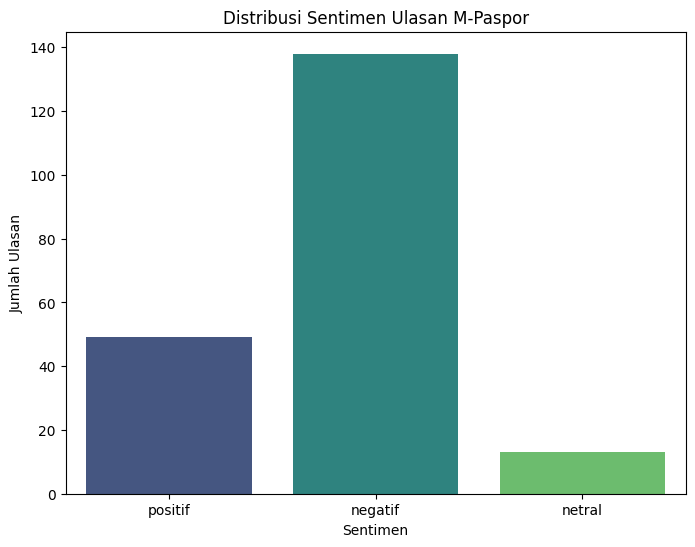

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart for sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df_gplay, palette='viridis')
plt.title('Distribusi Sentimen Ulasan M-Paspor')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

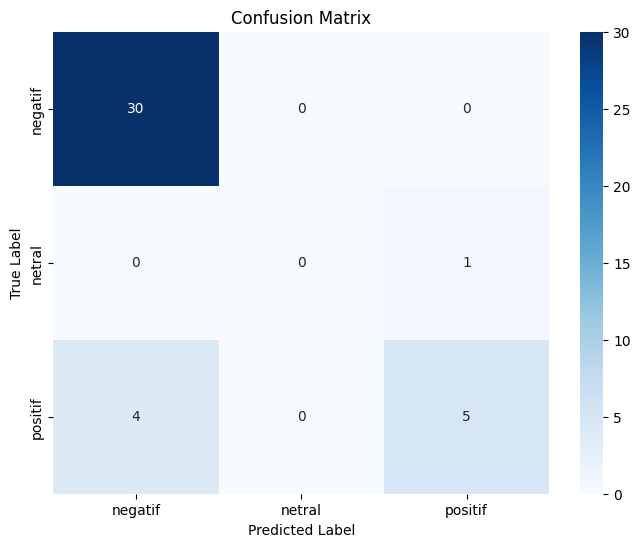

In [13]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Word Cloud Berdasarkan Sentimen

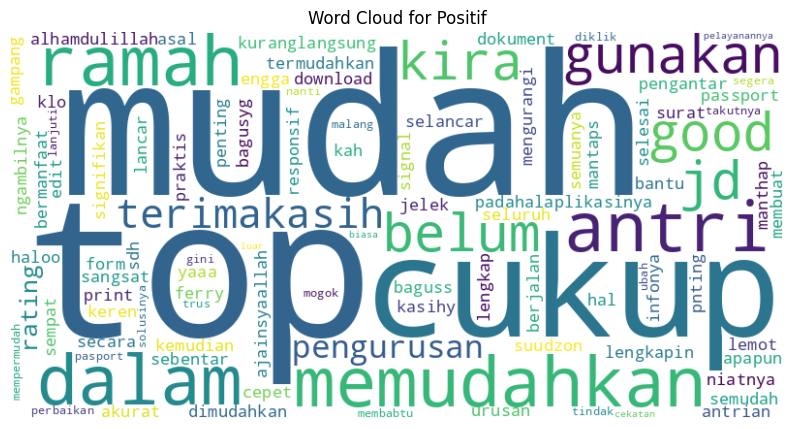

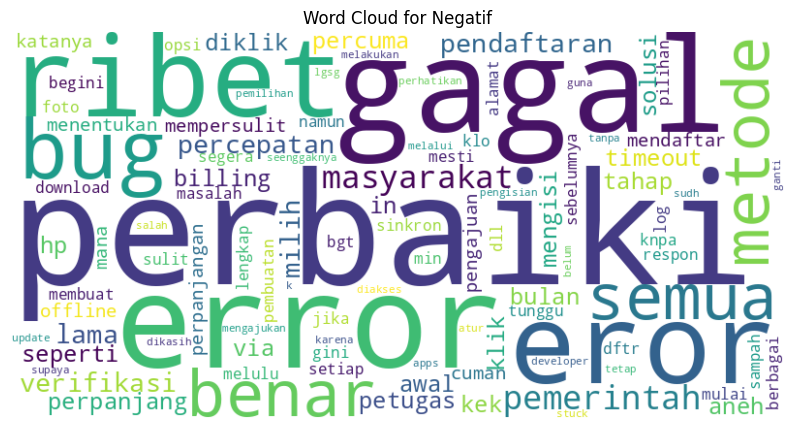

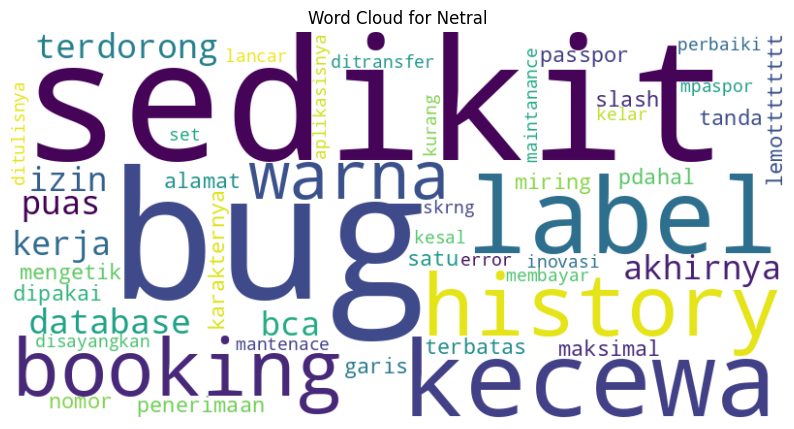

In [26]:
sentiments = df_gplay['label'].unique()

# Define specific keywords for clarity
negative_keywords = ['error', 'gagal', 'ribet', 'eror', 'perbaiki', 'aneh', 'bug', 'mempersulit', 'masalah', 'lama', 'kecewa']
positive_keywords = ['berguna', 'memudahkan'] # These are words that can be target to highlight positive sentiment

for sentiment in sentiments:
    text_sentiment = ' '.join(df_gplay[df_gplay['label'] == sentiment]['clean_text'])

    current_stopwords = set(final_stopwords) # Start with general stopwords (which exclude target_words)

    if sentiment == 'positif':
        # For positive reviews:
        # Add negative keywords to stopwords (to filter them out)
        current_stopwords.update(negative_keywords)
        # Ensure positive keywords are NOT in stopwords (to highlight them)
        current_stopwords.difference_update(positive_keywords)

    elif sentiment == 'negatif':
        # For negative reviews:
        # Add positive keywords to stopwords (they are not relevant for highlighting negative issues)
        current_stopwords.update(positive_keywords)
        # Ensure negative keywords are NOT in stopwords (to highlight them)
        current_stopwords.difference_update(negative_keywords)

    elif sentiment == 'netral':
        # For neutral reviews: add user-specified words to remove
        neutral_specific_stopwords = [
            'halaman', 'beranda', 'perjalan', 'kuning', 'kanim', 'hijau', 'pp', 'bilang',
            'menggunakan', 'karena', 'cirebon', 'tab', 'sia', 'batal',
            'bro', 'minggu', 'kan', 'spasi', 'menempuh', 'pengisian', 'sebelumnya', 'ulang', 'transaksi',
            'pajak', 'rumah', 'tambah', 'jumlah', 'merah', 'bbrp', 'aplikasinya', 'perjalanan', 'sat',
            'oleh', 'berwarna', 'karakternya skrg'
        ]
        current_stopwords.update(neutral_specific_stopwords)


    wordcloud_sentiment = WordCloud(
        width=800, height=400, background_color='white',
        stopwords=current_stopwords, max_words=100
    ).generate(text_sentiment)

    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud_sentiment, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {sentiment.capitalize()}')
    plt.show()

In [16]:
df_gplay.to_csv('m-paspor_google_play_reviews.csv', index=False)
print('File saved as m-paspor_google_play_reviews.csv')

File saved as m-paspor_google_play_reviews.csv


In [17]:
from google.colab import files
files.download('m-paspor_google_play_reviews.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>